In [ ]:
import pandas as pd 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB 
import string 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sensitivity import SensitivityAnalyzer

ImportError: Pandas requires version '3.1.5' or newer of 'jinja2' (version '3.1.4' currently installed).

In [ ]:
splits={'train': 'plain_text/train-00000-of-00001.parquet', 'test': 'plain_text/test-00000-of-00001.parquet', 'unsupervised': 'plain_text/unsupervised-00000-of-00001.parquet'}
data_train=pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["train"])
data_test=pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["test"])
data=pd.concat([data_train,data_test],ignore_index=True)
veri_listesi = data['text'].tolist()
print(data, len(veri_listesi))
pd.set_option('display.max_rows', 100)
print(data)
data.info()

                                                    text  label
0      I rented I AM CURIOUS-YELLOW from my video sto...      0
1      "I Am Curious: Yellow" is a risible and preten...      0
2      If only to avoid making this type of film in t...      0
3      This film was probably inspired by Godard's Ma...      0
4      Oh, brother...after hearing about this ridicul...      0
...                                                  ...    ...
49995  Just got around to seeing Monster Man yesterda...      1
49996  I got this as part of a competition prize. I w...      1
49997  I got Monster Man in a box set of three films ...      1
49998  Five minutes in, i started to feel how naff th...      1
49999  I caught this movie on the Sci-Fi channel rece...      1

[50000 rows x 2 columns] 50000
                                                    text  label
0      I rented I AM CURIOUS-YELLOW from my video sto...      0
1      "I Am Curious: Yellow" is a risible and preten...      0
2      I

In [ ]:
#data sentetic part
"""import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

synthetic_data_path = 'groq_sentetik_10000_ETIKETLI.csv'
df_synthetic = pd.read_csv(synthetic_data_path)

synthetic_corpus = df_synthetic['sentetik'].astype(str).tolist()
synthetic_labels = df_synthetic['label'].tolist()

print(f"Toplam sentetik metin sayısı: {len(synthetic_corpus)}")"""

In [ ]:
veri_listesi = data['text'].tolist()
print(data, len(veri_listesi))
pd.set_option('display.max_rows', 100)
print(data)
data.info()

In [ ]:
posts=[doc for doc in data.iloc[:,0]]
floors=[doc for doc in data.iloc[:,1]]
print(posts)
print("**************************************************************************")
print(floors)
#jupyter notebook --NotebookApp.iopub_data_rate_limit=1.0e10

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
import re
import nltk
import string
pd.set_option('display.max_rows', 100);
corpus=[]
for i in range (len(data)):
    posts=re.sub('[^a-zA-Z]',' ',str(data['text'][i]))
    posts=  posts.lower()
    posts=''.join( posts)
    corpus.append(posts)
    posts= " ".join(posts.split())
print(len(corpus))

50000


In [ ]:
vectorizer = TfidfVectorizer(ngram_range=(0,4))
X = vectorizer.fit_transform(corpus)

In [ ]:
y = data["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)
pd.set_option('display.max_rows', 100); 
print(X_train, X_test, y_train, y_test)

  (0, 0)	0.6611374198105577
  (0, 3738363)	0.01473643311870304
  (0, 5718572)	0.0045608047643472234
  (0, 10502296)	0.013592850684916155
  (0, 14635018)	0.07294959463722055
  (0, 14450147)	0.003128160555757636
  (0, 8008977)	0.0028827638415994464
  (0, 7303822)	0.01456026918379572
  (0, 452382)	0.006111069992469007
  (0, 1550720)	0.00430311028754329
  (0, 2742171)	0.013646167268923086
  (0, 7216572)	0.004745825677658074
  (0, 16037902)	0.016461098018869066
  (0, 3530195)	0.015909435432472623
  (0, 5492650)	0.00692058982684498
  (0, 7730039)	0.022962099834631548
  (0, 18270158)	0.008382620122380795
  (0, 17633432)	0.00929952090909103
  (0, 2864148)	0.005069537532136682
  (0, 8787811)	0.006992903384210016
  (0, 13611424)	0.005057793350697151
  (0, 10955681)	0.007569948521868712
  (0, 17462553)	0.0049694861656539606
  (0, 14115774)	0.007359338766123085
  (0, 1391449)	0.007476348659201432
  :	:
  (39999, 836144)	0.05047370427880733
  (39999, 8364368)	0.05047370427880733
  (39999, 8578841)	

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:

accuracy = accuracy_score(y_test, y_pred)
print(f"Doğruluk (Accuracy): {accuracy:.2f}")

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Kesinlik (Precision): {precision:.2f}")
print(f"Geri Çağırma (Recall): {recall:.2f}")
print(f"F1 Skoru: {f1:.2f}")

print("\nSınıf Bazında Değerlendirme:")
print(classification_report(y_test, y_pred))
sensitivity_per_class = recall_score(y_test, y_pred, average=None)
print(f"Her sınıf için sensitivity: {sensitivity_per_class}")

macro_sensitivity = recall_score(y_test, y_pred, average='macro')
print(f"Makro ortalama sensitivity: {macro_sensitivity:.2f}")

weighted_sensitivity = recall_score(y_test, y_pred, average='weighted')
print(f"Ağırlıklı ortalama sensitivity: {weighted_sensitivity:.2f}")

Doğruluk (Accuracy): 0.90
Kesinlik (Precision): 0.90
Geri Çağırma (Recall): 0.90
F1 Skoru: 0.90

Sınıf Bazında Değerlendirme:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      5055
           1       0.91      0.88      0.90      4945

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

Her sınıf için sensitivity: [0.91295747 0.88473205]
Makro ortalama sensitivity: 0.90
Ağırlıklı ortalama sensitivity: 0.90


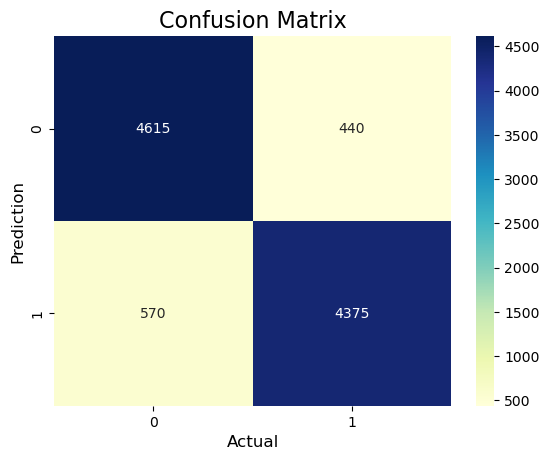

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
class_names = ["0", "1"]
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True,fmt='d',cmap='YlGnBu', xticklabels= class_names, yticklabels= class_names)
plt.ylabel('Prediction',fontsize=12)
plt.xlabel('Actual',fontsize=12)
plt.title('Confusion Matrix',fontsize=16)
plt.show()